# Arabic Text Summarization – Data Loading and Preprocessing

**Cell 1 — Imports**

In [194]:
import os
import re
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Cell 2 — Set dataset path**

In [195]:
DATASET_DIR = Path("./dataset")

print("Dataset folder exists:", DATASET_DIR.exists())
print("Dataset folder:", DATASET_DIR.resolve())

Dataset folder exists: True
Dataset folder: C:\Users\moham\Desktop\NLP_Project\dataset


**Cell 3 — List all files**

In [196]:
all_files = [p for p in DATASET_DIR.rglob("*") if p.is_file()]

print(f"Total files found: {len(all_files)}\n")
for f in all_files[:50]:
    print(f)

Total files found: 52

dataset\Arabic_Text_Summarisation\data.csv
dataset\Arabic_Text_Summarisation\summarizdataset.csv
dataset\AraSum\AbsArSumCorpus_DW_article tab lead.csv
dataset\AraSum\AraDPO.json
dataset\AraSum\AraRLHF.json
dataset\AraSum\README.md
dataset\Egyptian_Text_Summarisation\.gitattributes
dataset\Egyptian_Text_Summarisation\README.md
dataset\SumArabic\downloader.py
dataset\SumArabic\downloader_extractor.py
dataset\SumArabic\downloader_extractor_utils.py
dataset\SumArabic\sumarabic-1.0-index.jsonl.xz
dataset\SumArabic\sumarabic-1.0-ood.jsonl
dataset\SumArabic\sumarabic-1.0-test.jsonl
dataset\SumArabic\sumarabic-1.0-train.jsonl
dataset\SumArabic\sumarabic-1.0-valid.jsonl
dataset\SumArabic\__pycache__\downloader_extractor.cpython-313.pyc
dataset\SumArabic\__pycache__\downloader_extractor_utils.cpython-313.pyc
dataset\Egyptian_Text_Summarisation\.git\config
dataset\Egyptian_Text_Summarisation\.git\description
dataset\Egyptian_Text_Summarisation\.git\HEAD
dataset\Egyptian_Tex

**Cell 4 — Group files by extension**

In [197]:
from collections import Counter

ext_counts = Counter([f.suffix.lower() for f in all_files])
ext_counts

Counter({'': 17,
         '.sample': 14,
         '.jsonl': 4,
         '.csv': 3,
         '.py': 3,
         '.json': 2,
         '.md': 2,
         '.pyc': 2,
         '.xz': 1,
         '.parquet': 1,
         '.idx': 1,
         '.pack': 1,
         '.rev': 1})

**Cell 5 — Helper functions to load common file types**

This makes it easier to load CSV, JSON, or JSONL.

In [198]:
def load_csv_file(path):
    return pd.read_csv(path)

def load_excel_file(path):
    return pd.read_excel(path)

def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return pd.DataFrame(data) if isinstance(data, list) else data

def load_jsonl_file(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def try_load_file(path):
    suffix = path.suffix.lower()
    try:
        if suffix == ".csv":
            return load_csv_file(path)
        elif suffix in [".xlsx", ".xls"]:
            return load_excel_file(path)
        elif suffix == ".json":
            return load_json_file(path)
        elif suffix == ".jsonl":
            return load_jsonl_file(path)
        elif suffix == ".parquet":
            return pd.read_parquet(path)
        else:
            return None
    except Exception as e:
        print(f"Could not load {path.name}: {e}")
        return None

**Cell 6 — Try loading likely dataset files**

In [199]:
candidate_files = [f for f in all_files if f.suffix.lower() in [".csv", ".json", ".jsonl", ".xlsx", ".xls", ".parquet"]]

print("Candidate data files:")
for i, f in enumerate(candidate_files):
    print(f"{i}: {f}")

Candidate data files:
0: dataset\Arabic_Text_Summarisation\data.csv
1: dataset\Arabic_Text_Summarisation\summarizdataset.csv
2: dataset\AraSum\AbsArSumCorpus_DW_article tab lead.csv
3: dataset\AraSum\AraDPO.json
4: dataset\AraSum\AraRLHF.json
5: dataset\SumArabic\sumarabic-1.0-ood.jsonl
6: dataset\SumArabic\sumarabic-1.0-test.jsonl
7: dataset\SumArabic\sumarabic-1.0-train.jsonl
8: dataset\SumArabic\sumarabic-1.0-valid.jsonl
9: dataset\Egyptian_Text_Summarisation\data\train-00000-of-00001.parquet


## Load and process new file 0: `dataset\Arabic_Text_Summarisation\data.csv`


**Cell 7 — Load file by file**

In [200]:
file_index = 0 
selected_file = candidate_files[file_index]

print("Loading:", selected_file)

df = try_load_file(selected_file)

type(df)

Loading: dataset\Arabic_Text_Summarisation\data.csv


pandas.core.frame.DataFrame

**Cell 8 — Inspect the dataset**

In [201]:
if isinstance(df, pd.DataFrame):
    print("Shape:", df.shape)
    display(df.head())
    print("\nColumns:")
    print(df.columns.tolist())
else:
    print("Loaded object is not a DataFrame.")
    print(df)

Shape: (5227, 6)


,Processed Text,summarizer,len-text,len-summarize,text - summarize,done?
0,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,80,28,52,Yes
1,تحصل كتاب المصحف وقراءاته الفه باحثون تونسيون ...,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...",53,32,21,Yes
2,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائ...,216,27,189,Yes
3,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,\nتنطلق فعاليات التظاهرة الموسيقية الالكترونية...,66,21,45,Yes
4,ينطلق مهرجان القيروان للشعر العربي ببيت الشعر ...,وستلتأم خلال اليوم الثاني الندوة النقدية بعنوا...,157,63,94,Yes



Columns:
['Processed Text', 'summarizer', 'len-text', 'len-summarize', 'text - summarize', 'done?']


**Cell 9 — Check null values and duplicates**

In [202]:
if isinstance(df, pd.DataFrame):
    print("Null values per column:\n")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

Null values per column:

Processed Text      0
summarizer          0
len-text            0
len-summarize       0
text - summarize    0
done?               0
dtype: int64

Duplicate rows: 197


**Cell 10 — Identify the article and summary columns**

In [203]:

ARTICLE_COL = "Processed Text"  
SUMMARY_COL = "summarizer"  

print("Article column:", ARTICLE_COL)
print("Summary column:", SUMMARY_COL)

Article column: Processed Text
Summary column: summarizer


**Cell 11 — Keep only the important columns**

In [204]:
df = df[[ARTICLE_COL, SUMMARY_COL]].copy()
df = df.dropna(subset=[ARTICLE_COL, SUMMARY_COL]).drop_duplicates()

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (5030, 2)


,Processed Text,summarizer
0,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...
1,تحصل كتاب المصحف وقراءاته الفه باحثون تونسيون ...,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون..."
2,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائ...
3,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,\nتنطلق فعاليات التظاهرة الموسيقية الالكترونية...
4,ينطلق مهرجان القيروان للشعر العربي ببيت الشعر ...,وستلتأم خلال اليوم الثاني الندوة النقدية بعنوا...


**Cell 12 — Print raw Arabic examples**

In [205]:
for i in range(min(5, len(df))):
    print("=" * 80)
    print(f"Example {i+1}")
    print("\nARTICLE:\n")
    print(df.iloc[i][ARTICLE_COL])
    print("\nSUMMARY:\n")
    print(df.iloc[i][SUMMARY_COL])
    print()


Example 1

ARTICLE:

اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم بقصر قرطاج موكب منح الوسام الوطني للاستحقاق الثقافي الفنانين والمبدعين بمناسبه انعقاد ايام قرطاج السينمائيه والفنانون الصنف عبد الرحمان سيساكو موريتانيا جميل راتب مصر ميشال خليفي فلسطين ادريسا ودراغو بوركينا فاسو محمد ملص سوريا رضا الباهي تونس الحضور عمر الخليفي تونس الصنف الثاني عبد العزيز بن ملوكه تونس نجيب تونس منصف شرف الدين تونس الحضور الصنف الثالث ابراهيم تونس الخياطي تونس الحضور تونس عليها الحضور شوقي الماجري تونس الصنف الرابع كوثر بن تونس

SUMMARY:


أشرف رئيس الجمهورية الباجي قايد السبسي اليوم بقصر قرطاج على موكب منح الوسام الوطني للاستحقاق الثقافي لثلّة من الفنانين والمبدعين و ذلك بمناسبة انعقاد أيام قرطاج السينمائية.

Example 2

ARTICLE:

تحصل كتاب المصحف وقراءاته الفه باحثون تونسيون متخصصون جائزه عربيه هامش افتتاح معرض بيروت العربي الدولي للكتاب افتتح امس ويتواصل يوم الحالي واسند النادي الثقافي العربي الجائزه الثالثه ل المصحف وقراءاته جاء مجلدات وتم تصنيفه طرف مجموعه الباحثين باشراف الباحث التونسي الحضاره الا

**Cell 13 — Arabic preprocessing functions**

In [206]:
arabic_diacritics = re.compile("""
                             ّ    | # Tashdid
                             َ    | # Fatha
                             ً    | # Tanwin Fath
                             ُ    | # Damma
                             ٌ    | # Tanwin Damm
                             ِ    | # Kasra
                             ٍ    | # Tanwin Kasr
                             ْ    | # Sukun
                             ـ      # Tatwil/Kashida
                         """, re.VERBOSE)

def remove_diacritics(text):
    text = str(text)
    return re.sub(arabic_diacritics, "", text)

def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)   # you can keep ة if you prefer
    text = re.sub(r"گ", "ك", text)
    return text

def clean_arabic_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove diacritics
    text = remove_diacritics(text)
    
    # Normalize letters
    text = normalize_arabic(text)
    
    # Remove non-Arabic letters, digits, and common punctuation you don't want
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

**Cell 14 — Test preprocessing on a few rows**

In [207]:
sample_df = df.head(5).copy()

sample_df["clean_article"] = sample_df[ARTICLE_COL].apply(clean_arabic_text)
sample_df["clean_summary"] = sample_df[SUMMARY_COL].apply(clean_arabic_text)

for i in range(len(sample_df)):
    print("=" * 100)
    print(f"Sample {i+1}")
    
    print("\nORIGINAL ARTICLE:\n")
    print(sample_df.iloc[i][ARTICLE_COL])
    
    print("\nCLEAN ARTICLE:\n")
    print(sample_df.iloc[i]["clean_article"])
    
    print("\nORIGINAL SUMMARY:\n")
    print(sample_df.iloc[i][SUMMARY_COL])
    
    print("\nCLEAN SUMMARY:\n")
    print(sample_df.iloc[i]["clean_summary"])

Sample 1

ORIGINAL ARTICLE:

اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم بقصر قرطاج موكب منح الوسام الوطني للاستحقاق الثقافي الفنانين والمبدعين بمناسبه انعقاد ايام قرطاج السينمائيه والفنانون الصنف عبد الرحمان سيساكو موريتانيا جميل راتب مصر ميشال خليفي فلسطين ادريسا ودراغو بوركينا فاسو محمد ملص سوريا رضا الباهي تونس الحضور عمر الخليفي تونس الصنف الثاني عبد العزيز بن ملوكه تونس نجيب تونس منصف شرف الدين تونس الحضور الصنف الثالث ابراهيم تونس الخياطي تونس الحضور تونس عليها الحضور شوقي الماجري تونس الصنف الرابع كوثر بن تونس

CLEAN ARTICLE:

اشرف رييس الجمهوريه الباجي قايد السبسي اليوم بقصر قرطاج موكب منح الوسام الوطني للاستحقاق الثقافي الفنانين والمبدعين بمناسبه انعقاد ايام قرطاج السينماييه والفنانون الصنف عبد الرحمان سيساكو موريتانيا جميل راتب مصر ميشال خليفي فلسطين ادريسا ودراغو بوركينا فاسو محمد ملص سوريا رضا الباهي تونس الحضور عمر الخليفي تونس الصنف الثاني عبد العزيز بن ملوكه تونس نجيب تونس منصف شرف الدين تونس الحضور الصنف الثالث ابراهيم تونس الخياطي تونس الحضور تونس عليها الحضور شوقي ا

**Cell 15 — Apply preprocessing to the full dataset**

In [208]:
df["clean_article"] = df[ARTICLE_COL].astype(str).apply(clean_arabic_text)
df["clean_summary"] = df[SUMMARY_COL].astype(str).apply(clean_arabic_text)

display(df.head())

,Processed Text,summarizer,clean_article,clean_summary
0,اشرف رئيس الجمهوريه الباجي قايد السبسي اليوم ب...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,اشرف رييس الجمهوريه الباجي قايد السبسي اليوم ب...,اشرف رييس الجمهوريه الباجي قايد السبسي اليوم ب...
1,تحصل كتاب المصحف وقراءاته الفه باحثون تونسيون ...,"\nتحصل كتاب ""المصحف وقراءاته"" الذي ألفه باحثون...",تحصل كتاب المصحف وقراءاته الفه باحثون تونسيون ...,تحصل كتاب المصحف وقراءاته الذي الفه باحثون تون...
2,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضرة من جهة أخرى ستكون تونس حاضرة في قائ...,احتضن جناح تونس القريه الدوليه للافلام بمدينه ...,تونس حاضره من جهه اخري ستكون تونس حاضره في قاي...
3,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,\nتنطلق فعاليات التظاهرة الموسيقية الالكترونية...,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...,تنطلق فعاليات التظاهره الموسيقيه الالكترونيه ص...
4,ينطلق مهرجان القيروان للشعر العربي ببيت الشعر ...,وستلتأم خلال اليوم الثاني الندوة النقدية بعنوا...,ينطلق مهرجان القيروان للشعر العربي ببيت الشعر ...,وستلتام خلال اليوم الثاني الندوه النقديه بعنوا...


**Cell 16 — Simple tokenization**

In [209]:
def simple_tokenize(text):
    return str(text).split()

df["article_tokens"] = df["clean_article"].apply(simple_tokenize)
df["summary_tokens"] = df["clean_summary"].apply(simple_tokenize)

**Cell 17 — Length statistics**

In [210]:
df["article_len"] = df["article_tokens"].apply(len)
df["summary_len"] = df["summary_tokens"].apply(len)

print("Article length stats:")
print(df["article_len"].describe())

print("\nSummary length stats:")
print(df["summary_len"].describe())

Article length stats:
count    5030.000000
mean       84.148509
std        49.202008
min        24.000000
25%        52.000000
50%        70.000000
75%        98.000000
max       463.000000
Name: article_len, dtype: float64

Summary length stats:
count    5030.000000
mean       30.651292
std        13.075977
min         0.000000
25%        21.000000
50%        27.000000
75%        42.000000
max        62.000000
Name: summary_len, dtype: float64


**Cell 18 — Plot token length distributions**

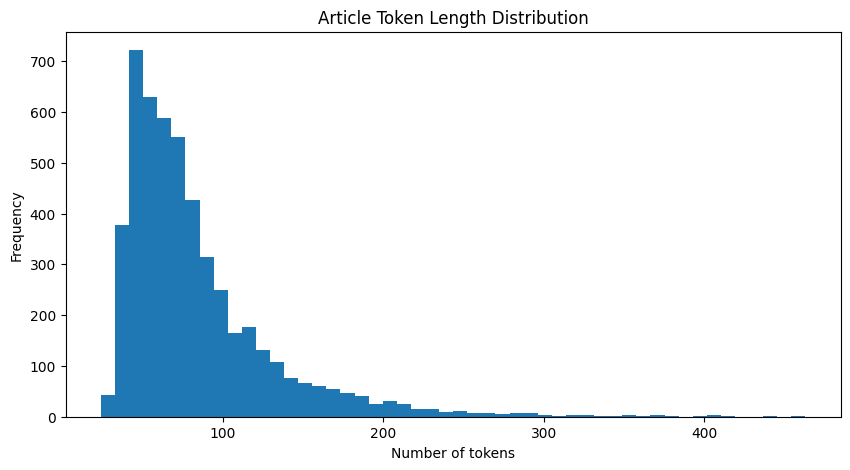

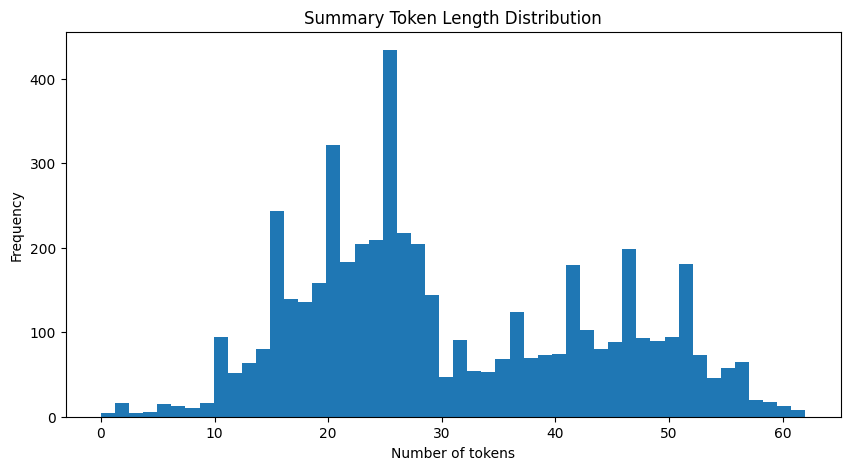

In [211]:
plt.figure(figsize=(10, 5))
plt.hist(df["article_len"], bins=50)
plt.title("Article Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["summary_len"], bins=50)
plt.title("Summary Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

**Cell 19 — Filter empty or extremely short rows**

In [212]:
df = df[
    (df["clean_article"].str.strip() != "") &
    (df["clean_summary"].str.strip() != "") &
    (df["article_len"] >= 5) &
    (df["summary_len"] >= 3)
].copy()

print("Shape after filtering:", df.shape)

Shape after filtering: (5010, 8)


**Cell 20 — Save a cleaned version**

In [213]:
OUTPUT_DIR = Path("./processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

folder_name = selected_file.parent.name
file_name = selected_file.stem  
output_path = OUTPUT_DIR / f"cleaned_{folder_name}_{file_name}.csv"

df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("Saved cleaned dataset to:", output_path.resolve())

Saved cleaned dataset to: C:\Users\moham\Desktop\NLP_Project\processed_data\cleaned_Arabic_Text_Summarisation_data.csv


## Load and process file 2: `dataset\AraSum\AbsArSumCorpus_DW_article tab lead.csv`


**Cell 7 — Load file by file**

In [214]:
file_index = 2
selected_file = candidate_files[file_index]

print("Loading:", selected_file)

df = pd.read_csv(selected_file, sep="\t", encoding="utf-8")

safe_file_name = re.sub(r"\s+", "_", selected_file.stem)
print("Safe filename:", safe_file_name)

print(type(df))
print(df.shape)
display(df.head())

Loading: dataset\AraSum\AbsArSumCorpus_DW_article tab lead.csv
Safe filename: AbsArSumCorpus_DW_article_tab_lead
<class 'pandas.core.frame.DataFrame'>
(49603, 3)


,0,"حقق حزب ""البديل من أجل ألمانيا"" اليميني الشعبوي أفضل نتائجه في أحدث استطلاعات الرأي بحصوله على تأييد 16% من الألمان في جميع أنحاء ألمانيا. وأظهر الاستطلاع الذي أجراه معهد ""إنفراتست ديماب"" بتكليف من شبكة (ARD)إيه آر دي الإعلامية الألمانية أن شعبية الحزب ارتفعت بذلك بنسبة 2% مقارنة باستطلاع مماثل أجري مطلع الشهر الجاري لشبكة(ZDF) تسي دي إف الإخبارية. وحصل التحالف المسيحي، المنتمية إليه المستشارة أنغيلا ميركل، في الاستطلاع الذي نشرت نتائجه اليوم الجمعة (23أيلول/ سبتمبر 2016 )على نسبة 32% بتراجع قدره 1% عن الاستطلاع السابق. كما تراجعت شعبية الحزب الاشتراكي الديمقراطي، الشريك في الائتلاف الحاكم، بنفس النسبة ليحصل على نسبة 22%. وفي المقابل، ارتفعت شعبية حزب الخضر بمقدار 1% لتصل إلى 12%، بينما تراجعت شعبية حزب ""اليسار"" بنسبة 1% ليحصل على نسبة 8%، في حين ارتفعت شعبية الحزب الديمقراطي الحر بنسبة 1% إلى 6%. وعن نتائج استطلاعات الرأي، قال وزير شؤون ديوان المستشارية بيتر ألتماير في تصريحات لـ""إيه آر دي"" إن استطلاعات الرأي لم تعد تبعث على التفاؤل بالنسبة لأي حزب من الأحزاب الممثلة في البرلمان الألماني (بوندستاغ). وأضاف ألتماير المنتمي إلى الحزب المسيحي الديمقراطي الذي تتزعمه المستشارة ميركل: ""هذا الأمر له علاقة بأننا نحل مشكلات صعبة في هذا البلد... لكننا متأكدون من أن نتائج الاستطلاعات ستتحسن عندما يتمكن المواطنون من رؤية واستشعار سيطرتنا على هذه المشكلات"". وشارك حوالي 934 ألمانيا فوق 18 عاما في الاستطلاع الذي أجري خلال الفترة من 19 حتى 21 أيلول/سبتمبر الجاري. ع.أ.ج/ ح ح (د ب أ)",تشير آخر استطلاعات الرأي الألمانية إلى تقدم حزب البديل اليميني في حين يستمر تراجع الحزب المسيحي الديمقراطي الذي تقوده المستشارة ميركل. وصرحت مصادر رسمية أن النتائج باتت غير مشجعة للأحزاب الموجودة في البرلمان الألماني.
0,1,بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ...,بدأت محكمة ميونخ النظر في اتهامات متعلقة برجل ...
1,2,قال مسؤولون إن شخصا أصيب إصابة بالغة بعد تعرضه...,أعلن حاكم كارولاينا الشمالية حالة الطورائ في م...
2,3,أعلن مسؤول في البنتاغون أن جنودا أمريكيين في ش...,قالت وزارة الدفاع الأمريكية (البنتاغون) إن داع...
3,4,اجتمعت المجموعة الدولية لدعم سوريا على هامش اج...,فشلت الولايات المتحدة وروسيا في الاتفاق على كي...
4,5,قال الإيطالي كارلو أنشيلوتي المدير الفني لفريق...,أثنى مدرب بايرن ميونيخ كارلو أنشيلوتي على مساع...


**Cell 8 — Inspect the dataset**

In [215]:
if isinstance(df, pd.DataFrame):
    print("Shape:", df.shape)

    print("\nOriginal columns:")
    print(df.columns.tolist())

    # Reset columns to numeric first
    df.columns = range(df.shape[1])

    # Keep only the first 3 columns
    df = df.iloc[:, :3].copy()

    # Rename them correctly
    df.columns = ["index", "article", "summary"]

    # Reset numbering if needed
    df = df.reset_index(drop=True)

    print("\nFinal columns:", df.columns.tolist())
    display(df.head())

else:
    print("Loaded object is not a DataFrame.")
    print(df)

Shape: (49603, 3)

Original columns:
['0', 'حقق حزب "البديل من أجل ألمانيا" اليميني الشعبوي أفضل نتائجه في أحدث استطلاعات الرأي بحصوله على تأييد 16% من الألمان في جميع أنحاء ألمانيا. وأظهر الاستطلاع الذي أجراه معهد "إنفراتست ديماب" بتكليف من شبكة (ARD)إيه آر دي الإعلامية الألمانية أن شعبية الحزب ارتفعت بذلك بنسبة 2% مقارنة باستطلاع مماثل أجري مطلع الشهر الجاري لشبكة(ZDF) تسي دي إف الإخبارية. وحصل التحالف المسيحي، المنتمية إليه المستشارة أنغيلا ميركل، في الاستطلاع الذي نشرت نتائجه اليوم الجمعة (23أيلول/ سبتمبر 2016 )على نسبة 32% بتراجع قدره 1% عن الاستطلاع السابق. كما تراجعت شعبية الحزب الاشتراكي الديمقراطي، الشريك في الائتلاف الحاكم، بنفس النسبة ليحصل على نسبة 22%. وفي المقابل، ارتفعت شعبية حزب الخضر بمقدار 1% لتصل إلى 12%، بينما تراجعت شعبية حزب "اليسار" بنسبة 1% ليحصل على نسبة 8%، في حين ارتفعت شعبية الحزب الديمقراطي الحر بنسبة 1% إلى 6%. وعن نتائج استطلاعات الرأي، قال وزير شؤون ديوان المستشارية بيتر ألتماير في تصريحات لـ"إيه آر دي" إن استطلاعات الرأي لم تعد تبعث على التفاؤل بالنسبة 

,index,article,summary
0,1,بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ...,بدأت محكمة ميونخ النظر في اتهامات متعلقة برجل ...
1,2,قال مسؤولون إن شخصا أصيب إصابة بالغة بعد تعرضه...,أعلن حاكم كارولاينا الشمالية حالة الطورائ في م...
2,3,أعلن مسؤول في البنتاغون أن جنودا أمريكيين في ش...,قالت وزارة الدفاع الأمريكية (البنتاغون) إن داع...
3,4,اجتمعت المجموعة الدولية لدعم سوريا على هامش اج...,فشلت الولايات المتحدة وروسيا في الاتفاق على كي...
4,5,قال الإيطالي كارلو أنشيلوتي المدير الفني لفريق...,أثنى مدرب بايرن ميونيخ كارلو أنشيلوتي على مساع...


**Cell 9 — Check null values and duplicates**

In [216]:
if isinstance(df, pd.DataFrame):
    print("Null values per column:\n")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

Null values per column:

index      0
article    0
summary    0
dtype: int64

Duplicate rows: 0


**Cell 10 — Identify the article and summary columns**

In [217]:

ARTICLE_COL = "article"  
SUMMARY_COL = "summary"  

print("Article column:", ARTICLE_COL)
print("Summary column:", SUMMARY_COL)

Article column: article
Summary column: summary


**Cell 11 — Keep only the important columns**

In [218]:
df = df[[ARTICLE_COL, SUMMARY_COL]].copy()
df = df.dropna(subset=[ARTICLE_COL, SUMMARY_COL]).drop_duplicates()

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (49581, 2)


,article,summary
0,بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ...,بدأت محكمة ميونخ النظر في اتهامات متعلقة برجل ...
1,قال مسؤولون إن شخصا أصيب إصابة بالغة بعد تعرضه...,أعلن حاكم كارولاينا الشمالية حالة الطورائ في م...
2,أعلن مسؤول في البنتاغون أن جنودا أمريكيين في ش...,قالت وزارة الدفاع الأمريكية (البنتاغون) إن داع...
3,اجتمعت المجموعة الدولية لدعم سوريا على هامش اج...,فشلت الولايات المتحدة وروسيا في الاتفاق على كي...
4,قال الإيطالي كارلو أنشيلوتي المدير الفني لفريق...,أثنى مدرب بايرن ميونيخ كارلو أنشيلوتي على مساع...


**Cell 12 — Print raw Arabic examples**

In [219]:
for i in range(min(5, len(df))):
    print("=" * 80)
    print(f"Example {i+1}")
    print("\nARTICLE:\n")
    print(df.iloc[i][ARTICLE_COL])
    print("\nSUMMARY:\n")
    print(df.iloc[i][SUMMARY_COL])
    print()


Example 1

ARTICLE:

بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ميونيخ محاكمة رجل من جمهورية الجبل الأسود ( مونتينيغرو)، اعتقل في ألمانيا للاشتباه في انه كان ينقل أسلحة قبل أيام من اعتداءات باريس التي حصلت في تشرين الثاني/نوفمبر العام الماضي. وتريد المحكمة معرفة عما إذا كانت هذه الأسلحة أعدت للاستخدام في هجمات فرنسا. وقالت المتحدثة إن المتهم "اعترف أنه كان على علم بوجود أسلحة في سيارته، لكنه لا يعرف ما إذا كانت ستستخدم لتنفيذ اعتداء". وأضافت المتحدثة أن الرجل الذي يبلغ الحادية والخمسين ويدعى فوسيليتش، ملاحق "بتهمة التآمر في الإعداد لأعمال عنف يهدد امن الدولة" الفرنسية. واعتقل الرجل في 5 تشرين الثاني/نوفمبر 2015 على طريق سريع في ولاية بافاريا، على مقربة من الحدود النمساوية. حيث عثر رجال الشرطة في سيارته على كمية من الأسلحة و عدد كبير من القنابل اليدوية وبنادق كالاشنيكوف ومسدسات ومتفجرات. و أدخل فوسيليتش في جهاز "جي.بي.اس" خاص به عنوانا في باريس، وقد عثر على هذا العنوان مكتوبا على قصاصة ورق أيضا،و كتب على الورقة رقم هاتف فرنسي عائد على الأرجح لمتعاون مع المتهم، لكن لم يتم التعرف إليه 

**Cell 13 — Arabic preprocessing functions**

In [220]:
arabic_diacritics = re.compile("""
                             ّ    | # Tashdid
                             َ    | # Fatha
                             ً    | # Tanwin Fath
                             ُ    | # Damma
                             ٌ    | # Tanwin Damm
                             ِ    | # Kasra
                             ٍ    | # Tanwin Kasr
                             ْ    | # Sukun
                             ـ      # Tatwil/Kashida
                         """, re.VERBOSE)

def remove_diacritics(text):
    text = str(text)
    return re.sub(arabic_diacritics, "", text)

def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)   # you can keep ة if you prefer
    text = re.sub(r"گ", "ك", text)
    return text

def clean_arabic_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove diacritics
    text = remove_diacritics(text)
    
    # Normalize letters
    text = normalize_arabic(text)
    
    # Remove non-Arabic letters, digits, and common punctuation you don't want
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

**Cell 14 — Test preprocessing on a few rows**

In [221]:
sample_df = df.head(5).copy()

sample_df["clean_article"] = sample_df[ARTICLE_COL].apply(clean_arabic_text)
sample_df["clean_summary"] = sample_df[SUMMARY_COL].apply(clean_arabic_text)

for i in range(len(sample_df)):
    print("=" * 100)
    print(f"Sample {i+1}")
    
    print("\nORIGINAL ARTICLE:\n")
    print(sample_df.iloc[i][ARTICLE_COL])
    
    print("\nCLEAN ARTICLE:\n")
    print(sample_df.iloc[i]["clean_article"])
    
    print("\nORIGINAL SUMMARY:\n")
    print(sample_df.iloc[i][SUMMARY_COL])
    
    print("\nCLEAN SUMMARY:\n")
    print(sample_df.iloc[i]["clean_summary"])

Sample 1

ORIGINAL ARTICLE:

بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ميونيخ محاكمة رجل من جمهورية الجبل الأسود ( مونتينيغرو)، اعتقل في ألمانيا للاشتباه في انه كان ينقل أسلحة قبل أيام من اعتداءات باريس التي حصلت في تشرين الثاني/نوفمبر العام الماضي. وتريد المحكمة معرفة عما إذا كانت هذه الأسلحة أعدت للاستخدام في هجمات فرنسا. وقالت المتحدثة إن المتهم "اعترف أنه كان على علم بوجود أسلحة في سيارته، لكنه لا يعرف ما إذا كانت ستستخدم لتنفيذ اعتداء". وأضافت المتحدثة أن الرجل الذي يبلغ الحادية والخمسين ويدعى فوسيليتش، ملاحق "بتهمة التآمر في الإعداد لأعمال عنف يهدد امن الدولة" الفرنسية. واعتقل الرجل في 5 تشرين الثاني/نوفمبر 2015 على طريق سريع في ولاية بافاريا، على مقربة من الحدود النمساوية. حيث عثر رجال الشرطة في سيارته على كمية من الأسلحة و عدد كبير من القنابل اليدوية وبنادق كالاشنيكوف ومسدسات ومتفجرات. و أدخل فوسيليتش في جهاز "جي.بي.اس" خاص به عنوانا في باريس، وقد عثر على هذا العنوان مكتوبا على قصاصة ورق أيضا،و كتب على الورقة رقم هاتف فرنسي عائد على الأرجح لمتعاون مع المتهم، لكن لم يتم التع

**Cell 15 — Apply preprocessing to the full dataset**

In [222]:
df["clean_article"] = df[ARTICLE_COL].astype(str).apply(clean_arabic_text)
df["clean_summary"] = df[SUMMARY_COL].astype(str).apply(clean_arabic_text)

display(df.head())

,article,summary,clean_article,clean_summary
0,بدأت اليوم الجمعة( 23 أيلول/ سبتمبر 2016 ) في ...,بدأت محكمة ميونخ النظر في اتهامات متعلقة برجل ...,بدات اليوم الجمعه ايلول سبتمبر في ميونيخ محاكم...,بدات محكمه ميونخ النظر في اتهامات متعلقه برجل ...
1,قال مسؤولون إن شخصا أصيب إصابة بالغة بعد تعرضه...,أعلن حاكم كارولاينا الشمالية حالة الطورائ في م...,قال مسوولون ان شخصا اصيب اصابه بالغه بعد تعرضه...,اعلن حاكم كارولاينا الشماليه حاله الطوراي في م...
2,أعلن مسؤول في البنتاغون أن جنودا أمريكيين في ش...,قالت وزارة الدفاع الأمريكية (البنتاغون) إن داع...,اعلن مسوول في البنتاغون ان جنودا امريكيين في ش...,قالت وزاره الدفاع الامريكيه البنتاغون ان داعش ...
3,اجتمعت المجموعة الدولية لدعم سوريا على هامش اج...,فشلت الولايات المتحدة وروسيا في الاتفاق على كي...,اجتمعت المجموعه الدوليه لدعم سوريا علي هامش اج...,فشلت الولايات المتحده وروسيا في الاتفاق علي كي...
4,قال الإيطالي كارلو أنشيلوتي المدير الفني لفريق...,أثنى مدرب بايرن ميونيخ كارلو أنشيلوتي على مساع...,قال الايطالي كارلو انشيلوتي المدير الفني لفريق...,اثني مدرب بايرن ميونيخ كارلو انشيلوتي علي مساع...


**Cell 16 — Simple tokenization**

In [223]:
def simple_tokenize(text):
    return str(text).split()

df["article_tokens"] = df["clean_article"].apply(simple_tokenize)
df["summary_tokens"] = df["clean_summary"].apply(simple_tokenize)

**Cell 17 — Length statistics**

In [224]:
df["article_len"] = df["article_tokens"].apply(len)
df["summary_len"] = df["summary_tokens"].apply(len)

print("Article length stats:")
print(df["article_len"].describe())

print("\nSummary length stats:")
print(df["summary_len"].describe())

Article length stats:
count    49581.000000
mean       374.682883
std        221.195375
min         32.000000
25%        220.000000
50%        314.000000
75%        473.000000
max       2856.000000
Name: article_len, dtype: float64

Summary length stats:
count    49581.000000
mean        33.393699
std          3.718045
min          2.000000
25%         31.000000
50%         34.000000
75%         36.000000
max         44.000000
Name: summary_len, dtype: float64


**Cell 18 — Plot token length distributions**

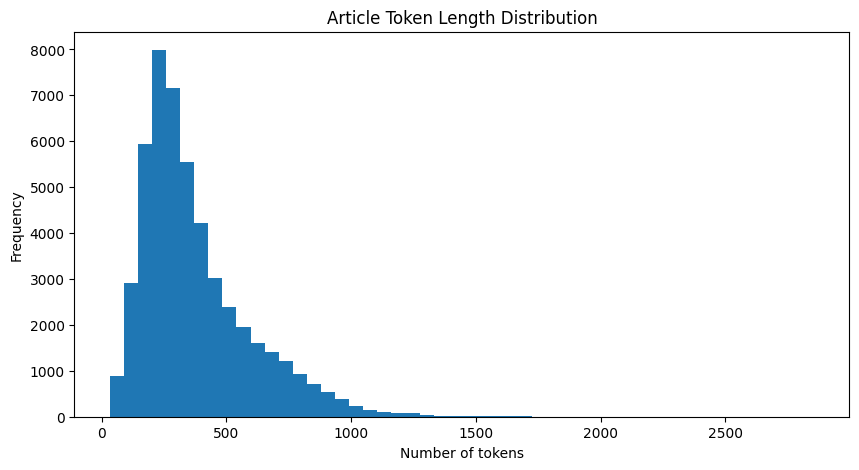

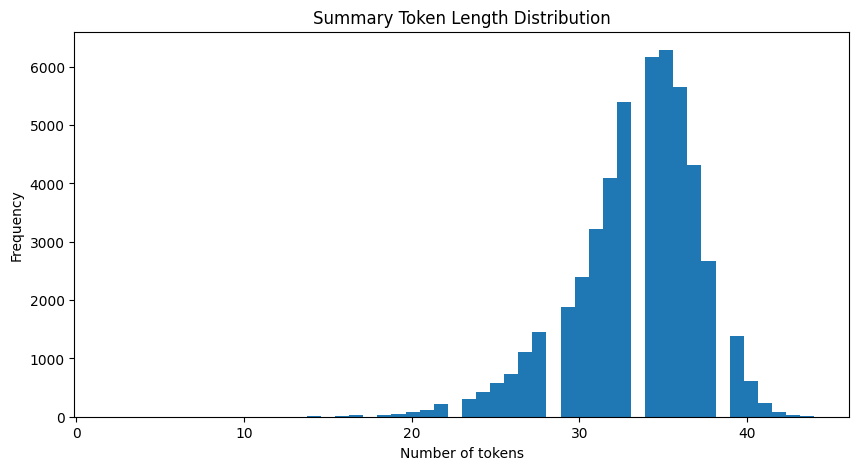

In [225]:
plt.figure(figsize=(10, 5))
plt.hist(df["article_len"], bins=50)
plt.title("Article Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["summary_len"], bins=50)
plt.title("Summary Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

**Cell 19 — Filter empty or extremely short rows**

In [226]:
df = df[
    (df["clean_article"].str.strip() != "") &
    (df["clean_summary"].str.strip() != "") &
    (df["article_len"] >= 5) &
    (df["summary_len"] >= 3)
].copy()

print("Shape after filtering:", df.shape)

Shape after filtering: (49579, 8)


**Cell 20 — Save a cleaned version**

In [227]:
OUTPUT_DIR = Path("./processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

folder_name = selected_file.parent.name
file_name = selected_file.stem  
output_path = OUTPUT_DIR / f"cleaned_{folder_name}_{file_name}.csv"

df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("Saved cleaned dataset to:", output_path.resolve())

Saved cleaned dataset to: C:\Users\moham\Desktop\NLP_Project\processed_data\cleaned_AraSum_AbsArSumCorpus_DW_article tab lead.csv


## Load and process new file 5: `dataset\SumArabic\sumarabic-1.0-XXXXX.jsonl`


**Cell 7 — Load file by file**

In [228]:
from pathlib import Path

DATASET_DIR = Path("./dataset/SumArabic")

sumarabic_files = {
    "train": DATASET_DIR / "sumarabic-1.0-train.jsonl",
    "valid": DATASET_DIR / "sumarabic-1.0-valid.jsonl",
    "test":  DATASET_DIR / "sumarabic-1.0-test.jsonl",
    "ood":   DATASET_DIR / "sumarabic-1.0-ood.jsonl",
}

import json
import pandas as pd

def load_jsonl_file(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

dfs = []

for split_name, file_path in sumarabic_files.items():
    
    print("Loading:", file_path)

    df = load_jsonl_file(file_path)

    # Add split identifier column
    df["split"] = split_name

    dfs.append(df)


Loading: dataset\SumArabic\sumarabic-1.0-train.jsonl
Loading: dataset\SumArabic\sumarabic-1.0-valid.jsonl
Loading: dataset\SumArabic\sumarabic-1.0-test.jsonl
Loading: dataset\SumArabic\sumarabic-1.0-ood.jsonl


**Cell 8 — Inspect the dataset**

In [229]:

df = pd.concat(dfs, ignore_index=True)

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (84764, 11)


,dataset,filename,headline,length,offset,published,section,subdomain,text,url,split
0,train,crawl-data/CC-MAIN-2019-04/segments/1547583705...,المصري فؤاد الطاهر بطل للشطرنج الديناميكي,14478,750279704,2008-02-03 00:00+0400,emaratalyoum.com,emaratalyoum.com,اختتمت مساء أول من أمس نهائيات بطولة الإمارات ...,https://www.emaratalyoum.com/local-section/200...,train
1,train,crawl-data/CC-MAIN-2019-13/segments/1552912202...,"حملة انتخابية محمومة قبل ""الثلاثاء الكبير""",15030,770295734,2008-02-03 00:00+0400,emaratalyoum.com,emaratalyoum.com,مينيابوليس (الولايات المتحدة) 3-2-2008 (ا ف ب)...,https://www.emaratalyoum.com/local-section/200...,train
2,train,crawl-data/CC-MAIN-2019-04/segments/1547583662...,55% من نزلاء «الأحداث» مواطنون,16581,789406684,2008-02-04 00:00+0400,emaratalyoum.com,emaratalyoum.com,أفاد مصدر في شرطة أبوظبي بأن نحو 700 طفل يتواف...,https://www.emaratalyoum.com/local-section/200...,train
3,train,crawl-data/CC-MAIN-2019-13/segments/1552912204...,مركز متخصص في الكلى بمستشفى خليفة,16661,754857257,2008-02-05 00:00+0400,emaratalyoum.com,emaratalyoum.com,قال استشاري أمراض الكلى في مدينة الشيخ خليفة ا...,https://www.emaratalyoum.com/local-section/200...,train
4,train,crawl-data/CC-MAIN-2018-39/segments/1537267155...,تأهيل ضحايا حوادث المرور في أبوظبي,14583,712490285,2008-02-05 00:00+0400,emaratalyoum.com,emaratalyoum.com,بدأت القيادة العامة لشرطة أبوظبي التنسيق لإنشا...,https://www.emaratalyoum.com/local-section/200...,train


**Cell 9 — Check null values and duplicates**

In [230]:
if isinstance(df, pd.DataFrame):
    print("Null values per column:\n")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

Null values per column:

dataset      0
filename     0
headline     0
length       0
offset       0
published    0
section      0
subdomain    0
text         0
url          0
split        0
dtype: int64

Duplicate rows: 0


**Cell 10 — Identify the article and summary columns**

In [231]:
df = df.rename(columns={
    "text": "article",
    "headline": "summary"
})

df = df.dropna(subset=["article", "summary"])

ARTICLE_COL = "article"
SUMMARY_COL = "summary"
print("Article column:", ARTICLE_COL)
print("Summary column:", SUMMARY_COL)

Article column: article
Summary column: summary


**Cell 11 — Keep only the important columns**

In [232]:
df = df.dropna(subset=[ARTICLE_COL, SUMMARY_COL]).drop_duplicates()

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (84764, 11)


,dataset,filename,summary,length,offset,published,section,subdomain,article,url,split
0,train,crawl-data/CC-MAIN-2019-04/segments/1547583705...,المصري فؤاد الطاهر بطل للشطرنج الديناميكي,14478,750279704,2008-02-03 00:00+0400,emaratalyoum.com,emaratalyoum.com,اختتمت مساء أول من أمس نهائيات بطولة الإمارات ...,https://www.emaratalyoum.com/local-section/200...,train
1,train,crawl-data/CC-MAIN-2019-13/segments/1552912202...,"حملة انتخابية محمومة قبل ""الثلاثاء الكبير""",15030,770295734,2008-02-03 00:00+0400,emaratalyoum.com,emaratalyoum.com,مينيابوليس (الولايات المتحدة) 3-2-2008 (ا ف ب)...,https://www.emaratalyoum.com/local-section/200...,train
2,train,crawl-data/CC-MAIN-2019-04/segments/1547583662...,55% من نزلاء «الأحداث» مواطنون,16581,789406684,2008-02-04 00:00+0400,emaratalyoum.com,emaratalyoum.com,أفاد مصدر في شرطة أبوظبي بأن نحو 700 طفل يتواف...,https://www.emaratalyoum.com/local-section/200...,train
3,train,crawl-data/CC-MAIN-2019-13/segments/1552912204...,مركز متخصص في الكلى بمستشفى خليفة,16661,754857257,2008-02-05 00:00+0400,emaratalyoum.com,emaratalyoum.com,قال استشاري أمراض الكلى في مدينة الشيخ خليفة ا...,https://www.emaratalyoum.com/local-section/200...,train
4,train,crawl-data/CC-MAIN-2018-39/segments/1537267155...,تأهيل ضحايا حوادث المرور في أبوظبي,14583,712490285,2008-02-05 00:00+0400,emaratalyoum.com,emaratalyoum.com,بدأت القيادة العامة لشرطة أبوظبي التنسيق لإنشا...,https://www.emaratalyoum.com/local-section/200...,train


**Cell 12 — Print raw Arabic examples**

In [233]:
for i in range(min(5, len(df))):
    print("=" * 80)
    print(f"Example {i+1}")
    print("\nARTICLE:\n")
    print(df.iloc[i][ARTICLE_COL])
    print("\nSUMMARY:\n")
    print(df.iloc[i][SUMMARY_COL])
    print()


Example 1

ARTICLE:

اختتمت مساء أول من أمس نهائيات بطولة الإمارات للشطرنج الديناميكي المفتوحة التي نظمها اتحاد الإمارات للشطرنج بمقر نادي دبي للشطرنج والثقافة حيث توج الأستاذ الدولي المصري فؤاد الطاهر بطلا للمسابقة برصيد 6 نقاط من 7 جولات.

SUMMARY:

المصري فؤاد الطاهر بطل للشطرنج الديناميكي

Example 2

ARTICLE:

مينيابوليس (الولايات المتحدة) 3-2-2008 (ا ف ب) - توقع المرشح الجمهوري جون

SUMMARY:

حملة انتخابية محمومة قبل "الثلاثاء الكبير"

Example 3

ARTICLE:

أفاد مصدر في شرطة أبوظبي بأن نحو 700 طفل يتوافدون على مركز رعاية الأحداث سنوياً، 55% منهم مواطنون و45% مقيمون. 

SUMMARY:

55% من نزلاء «الأحداث» مواطنون

Example 4

ARTICLE:

قال استشاري أمراض الكلى في مدينة الشيخ خليفة الطبية في أبوظبي الدكتور ياسين شحات، إن المدينة ستطلق قريباً مشروعات وأبحاثا لمعرفة معدلات انتشار أمراض الكلى في أبوظبي وأسباب الإصابة بها، إلى جانب وضع الخطط والاستراتيجيات الوقائية والعلاجية الواجب تنفيذها لمواجهة المرض».

SUMMARY:

مركز متخصص في الكلى بمستشفى خليفة

Example 5

ARTICLE:

بدأت القيادة العامة لش

**Cell 13 — Arabic preprocessing functions**

In [234]:
arabic_diacritics = re.compile("""
                             ّ    | # Tashdid
                             َ    | # Fatha
                             ً    | # Tanwin Fath
                             ُ    | # Damma
                             ٌ    | # Tanwin Damm
                             ِ    | # Kasra
                             ٍ    | # Tanwin Kasr
                             ْ    | # Sukun
                             ـ      # Tatwil/Kashida
                         """, re.VERBOSE)

def remove_diacritics(text):
    text = str(text)
    return re.sub(arabic_diacritics, "", text)

def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)   # you can keep ة if you prefer
    text = re.sub(r"گ", "ك", text)
    return text

def clean_arabic_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove diacritics
    text = remove_diacritics(text)
    
    # Normalize letters
    text = normalize_arabic(text)
    
    # Remove non-Arabic letters, digits, and common punctuation you don't want
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

**Cell 14 — Test preprocessing on a few rows**

In [235]:
sample_df = df.head(5).copy()

sample_df["clean_article"] = sample_df[ARTICLE_COL].apply(clean_arabic_text)
sample_df["clean_summary"] = sample_df[SUMMARY_COL].apply(clean_arabic_text)

for i in range(len(sample_df)):
    print("=" * 100)
    print(f"Sample {i+1}")
    
    print("\nORIGINAL ARTICLE:\n")
    print(sample_df.iloc[i][ARTICLE_COL])
    
    print("\nCLEAN ARTICLE:\n")
    print(sample_df.iloc[i]["clean_article"])
    
    print("\nORIGINAL SUMMARY:\n")
    print(sample_df.iloc[i][SUMMARY_COL])
    
    print("\nCLEAN SUMMARY:\n")
    print(sample_df.iloc[i]["clean_summary"])

Sample 1

ORIGINAL ARTICLE:

اختتمت مساء أول من أمس نهائيات بطولة الإمارات للشطرنج الديناميكي المفتوحة التي نظمها اتحاد الإمارات للشطرنج بمقر نادي دبي للشطرنج والثقافة حيث توج الأستاذ الدولي المصري فؤاد الطاهر بطلا للمسابقة برصيد 6 نقاط من 7 جولات.

CLEAN ARTICLE:

اختتمت مساء اول من امس نهاييات بطوله الامارات للشطرنج الديناميكي المفتوحه التي نظمها اتحاد الامارات للشطرنج بمقر نادي دبي للشطرنج والثقافه حيث توج الاستاذ الدولي المصري فواد الطاهر بطلا للمسابقه برصيد نقاط من جولات

ORIGINAL SUMMARY:

المصري فؤاد الطاهر بطل للشطرنج الديناميكي

CLEAN SUMMARY:

المصري فواد الطاهر بطل للشطرنج الديناميكي
Sample 2

ORIGINAL ARTICLE:

مينيابوليس (الولايات المتحدة) 3-2-2008 (ا ف ب) - توقع المرشح الجمهوري جون

CLEAN ARTICLE:

مينيابوليس الولايات المتحده ا ف ب توقع المرشح الجمهوري جون

ORIGINAL SUMMARY:

حملة انتخابية محمومة قبل "الثلاثاء الكبير"

CLEAN SUMMARY:

حمله انتخابيه محمومه قبل الثلاثاء الكبير
Sample 3

ORIGINAL ARTICLE:

أفاد مصدر في شرطة أبوظبي بأن نحو 700 طفل يتوافدون على مركز رعاية الأح

**Cell 15 — Apply preprocessing to the full dataset**

In [236]:
df["clean_article"] = df[ARTICLE_COL].astype(str).apply(clean_arabic_text)
df["clean_summary"] = df[SUMMARY_COL].astype(str).apply(clean_arabic_text)

display(df.head())

,dataset,filename,summary,length,offset,published,section,subdomain,article,url,split,clean_article,clean_summary
0,train,crawl-data/CC-MAIN-2019-04/segments/1547583705...,المصري فؤاد الطاهر بطل للشطرنج الديناميكي,14478,750279704,2008-02-03 00:00+0400,emaratalyoum.com,emaratalyoum.com,اختتمت مساء أول من أمس نهائيات بطولة الإمارات ...,https://www.emaratalyoum.com/local-section/200...,train,اختتمت مساء اول من امس نهاييات بطوله الامارات ...,المصري فواد الطاهر بطل للشطرنج الديناميكي
1,train,crawl-data/CC-MAIN-2019-13/segments/1552912202...,"حملة انتخابية محمومة قبل ""الثلاثاء الكبير""",15030,770295734,2008-02-03 00:00+0400,emaratalyoum.com,emaratalyoum.com,مينيابوليس (الولايات المتحدة) 3-2-2008 (ا ف ب)...,https://www.emaratalyoum.com/local-section/200...,train,مينيابوليس الولايات المتحده ا ف ب توقع المرشح ...,حمله انتخابيه محمومه قبل الثلاثاء الكبير
2,train,crawl-data/CC-MAIN-2019-04/segments/1547583662...,55% من نزلاء «الأحداث» مواطنون,16581,789406684,2008-02-04 00:00+0400,emaratalyoum.com,emaratalyoum.com,أفاد مصدر في شرطة أبوظبي بأن نحو 700 طفل يتواف...,https://www.emaratalyoum.com/local-section/200...,train,افاد مصدر في شرطه ابوظبي بان نحو طفل يتوافدون ...,من نزلاء الاحداث مواطنون
3,train,crawl-data/CC-MAIN-2019-13/segments/1552912204...,مركز متخصص في الكلى بمستشفى خليفة,16661,754857257,2008-02-05 00:00+0400,emaratalyoum.com,emaratalyoum.com,قال استشاري أمراض الكلى في مدينة الشيخ خليفة ا...,https://www.emaratalyoum.com/local-section/200...,train,قال استشاري امراض الكلي في مدينه الشيخ خليفه ا...,مركز متخصص في الكلي بمستشفي خليفه
4,train,crawl-data/CC-MAIN-2018-39/segments/1537267155...,تأهيل ضحايا حوادث المرور في أبوظبي,14583,712490285,2008-02-05 00:00+0400,emaratalyoum.com,emaratalyoum.com,بدأت القيادة العامة لشرطة أبوظبي التنسيق لإنشا...,https://www.emaratalyoum.com/local-section/200...,train,بدات القياده العامه لشرطه ابوظبي التنسيق لانشا...,تاهيل ضحايا حوادث المرور في ابوظبي


**Cell 16 — Simple tokenization**

In [237]:
def simple_tokenize(text):
    return str(text).split()

df["article_tokens"] = df["clean_article"].apply(simple_tokenize)
df["summary_tokens"] = df["clean_summary"].apply(simple_tokenize)

**Cell 17 — Length statistics**

In [238]:
df["article_len"] = df["article_tokens"].apply(len)
df["summary_len"] = df["summary_tokens"].apply(len)

print("Article length stats:")
print(df["article_len"].describe())

print("\nSummary length stats:")
print(df["summary_len"].describe())

Article length stats:
count    84764.000000
mean        33.203235
std         10.958500
min          7.000000
25%         25.000000
50%         32.000000
75%         40.000000
max         75.000000
Name: article_len, dtype: float64

Summary length stats:
count    84764.000000
mean         8.104077
std          2.005672
min          0.000000
25%          7.000000
50%          8.000000
75%          9.000000
max         17.000000
Name: summary_len, dtype: float64


**Cell 18 — Plot token length distributions**

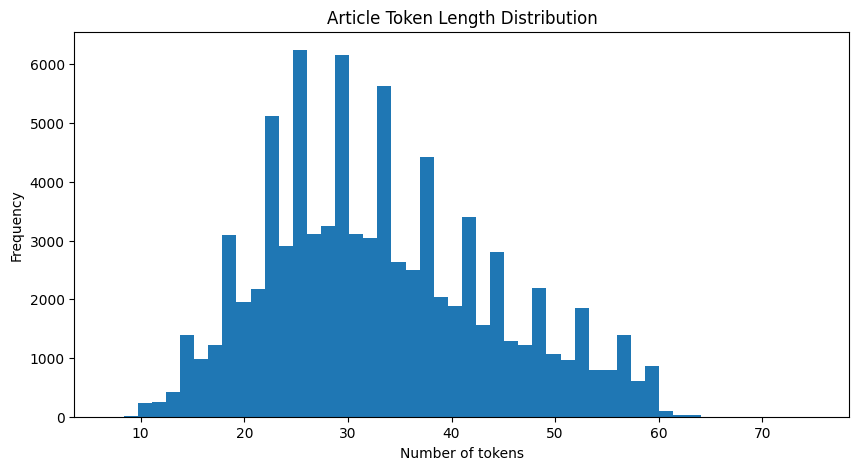

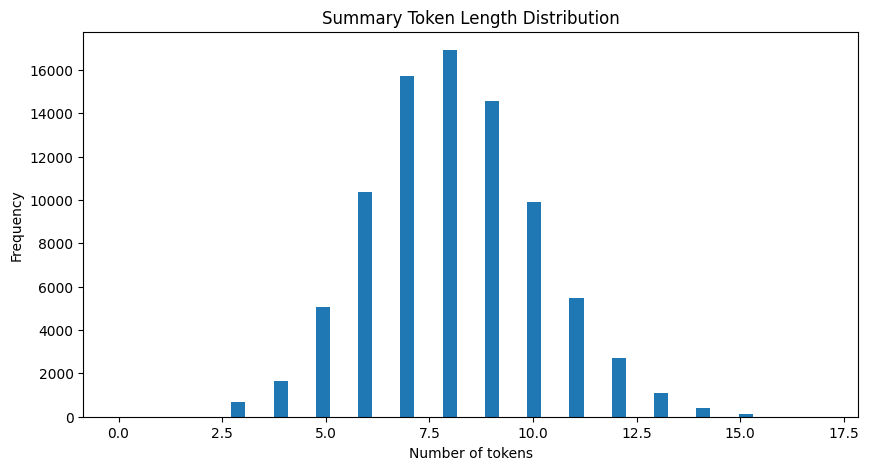

In [239]:
plt.figure(figsize=(10, 5))
plt.hist(df["article_len"], bins=50)
plt.title("Article Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["summary_len"], bins=50)
plt.title("Summary Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

**Cell 19 — Filter empty or extremely short rows**

In [240]:
df1 = df[
    (df["clean_article"].str.strip() != "") &
    (df["clean_summary"].str.strip() != "") &
    (df["article_len"] >= 5) &
    (df["summary_len"] >= 3)
].copy()

print("Shape after filtering:", df1.shape)

Shape after filtering: (84753, 17)


**Cell 20 — Save a cleaned version**

In [241]:
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df  = df[df["split"] == "test"]
ood_df   = df[df["split"] == "ood"]

In [242]:
OUTPUT_DIR = Path("./processed_data/SumArabic")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(OUTPUT_DIR/"train.csv", index=False, encoding="utf-8-sig")
valid_df.to_csv(OUTPUT_DIR/"valid.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(OUTPUT_DIR/"test.csv", index=False, encoding="utf-8-sig")
ood_df.to_csv(OUTPUT_DIR/"ood.csv", index=False, encoding="utf-8-sig")

## Load and process new file 6: `dataset\Egyptian_Text_Summarisation\data\train-00000-of-00001.parquet`


**Cell 7 — Load file by file**

In [243]:
file_index = 6
selected_file = candidate_files[file_index]

print("Loading:", selected_file)

df = try_load_file(selected_file)

type(df)

Loading: dataset\SumArabic\sumarabic-1.0-test.jsonl


pandas.core.frame.DataFrame

**Cell 8 — Inspect the dataset**

In [244]:
if isinstance(df, pd.DataFrame):
    print("Shape:", df.shape)
    display(df.head())
    print("\nColumns:")
    print(df.columns.tolist())
else:
    print("Loaded object is not a DataFrame.")
    print(df)

Shape: (4174, 10)


,dataset,filename,headline,length,offset,published,section,subdomain,text,url
0,test,crawl-data/CC-MAIN-2019-04/segments/1547583705...,ولي عهد دبي يدعم مهرجان الهجن بـ106 سيارات,15032,775917895,2008-02-05 00:00+0400,emaratalyoum.com,emaratalyoum.com,قدم سمو الشيخ حمدان بن محمد بن راشد آل مكتوم و...,https://www.emaratalyoum.com/local-section/200...
1,test,crawl-data/CC-MAIN-2018-34/segments/1534221214...,بطولة حمدان بن محمد للصيد بالصقور تتوج 15 بطلاً,16245,882619520,2008-02-06 00:00+0400,emaratalyoum.com,emaratalyoum.com,اختتمت بطولة الشيخ حمدان بن محمد بن راشد آل مك...,https://www.emaratalyoum.com/local-section/200...
2,test,crawl-data/CC-MAIN-2018-43/segments/1539583512...,عضو في «فينوغراد» يلمّح إلى محاباة أولمرت,14619,913694109,2008-02-07 00:00+0400,emaratalyoum.com,emaratalyoum.com,أثار أحد الأعضاء الخمسة في لجنة التحقيق الإسرا...,https://www.emaratalyoum.com/local-section/200...
3,test,crawl-data/CC-MAIN-2018-34/segments/1534221215...,«موانئ دبي» تناول 11 مليون حاوية,14714,892887631,2008-02-07 00:00+0400,emaratalyoum.com,emaratalyoum.com,أعلنت موانئ دبي العالمية، أن حجم المناولة في ج...,https://www.emaratalyoum.com/local-section/200...
4,test,crawl-data/CC-MAIN-2018-39/segments/1537267159...,رحلات ترفيهية للطلاب في الباص المائي,13904,718817895,2008-02-11 00:00+0400,emaratalyoum.com,emaratalyoum.com,قال مدير إدارة التشغيل والأداء في مؤسسة النقل ...,https://www.emaratalyoum.com/local-section/200...



Columns:
['dataset', 'filename', 'headline', 'length', 'offset', 'published', 'section', 'subdomain', 'text', 'url']


**Cell 9 — Check null values and duplicates**

In [245]:
if isinstance(df, pd.DataFrame):
    print("Null values per column:\n")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

Null values per column:

dataset      0
filename     0
headline     0
length       0
offset       0
published    0
section      0
subdomain    0
text         0
url          0
dtype: int64

Duplicate rows: 0


**Cell 10 — Identify the article and summary columns**

In [246]:

ARTICLE_COL = "text"  
SUMMARY_COL = "summarized_text"  

print("Article column:", ARTICLE_COL)
print("Summary column:", SUMMARY_COL)

Article column: text
Summary column: summarized_text


**Cell 11 — Keep only the important columns**

In [247]:
df = df[[ARTICLE_COL, SUMMARY_COL]].copy()
df = df.dropna(subset=[ARTICLE_COL, SUMMARY_COL]).drop_duplicates()

print("Cleaned shape:", df.shape)
display(df.head())

KeyError: "['summarized_text'] not in index"

**Cell 12 — Print raw Arabic examples**

In [ ]:
for i in range(min(5, len(df))):
    print("=" * 80)
    print(f"Example {i+1}")
    print("\nARTICLE:\n")
    print(df.iloc[i][ARTICLE_COL])
    print("\nSUMMARY:\n")
    print(df.iloc[i][SUMMARY_COL])
    print()


Example 1

ARTICLE:

كتير من الشباب دلوقتي بيفكروا ألف مرة قبل ما ياخدوا قرار الإنجاب، خصوصًا مع غلاء الأسعار اللي بنشوفه كل يوم. تكاليف تربية طفل واحد بس بقت مرهقة جدًا، من مصاريف الأكل والشرب واللبس، لحد التعليم والصحة. كل ده بيخلي الأسر تفكر تقلل عدد الأطفال عشان تقدر توفر حياة كريمة للي موجودين.

SUMMARY:

غلاء المعيشة بيخلي الشباب يقللوا عدد الأطفال بسبب صعوبة توفير احتياجاتهم الأساسية وتكاليف التربية المرتفعة.

Example 2

ARTICLE:

الظروف الاقتصادية الصعبة خلت كتير من الشباب يأجلوا خطوة الجواز والإنجاب، عشان مش عايزين يجيبوا أطفال في ظل وضع مادي غير مستقر. الأولية بقت لتأمين المستقبل المادي قبل تكوين أسرة.

SUMMARY:

الوضع الاقتصادي المتردي بيأجل قرارات الجواز والإنجاب عند الشباب لتأمين مستقبلهم المادي.

Example 3

ARTICLE:

موجات التضخم المتتالية أثرت بشكل مباشر على قدرة الأسر على التخطيط للمستقبل، وده بيشمل طبعًا قرار الإنجاب. لما أسعار السلع الأساسية بتزيد بشكل جنوني، الأسر بتضطر تعيد حساباتها وتبص على الأولويات، وممكن ده يخليهم يفكروا مرتين قبل ما يضيفوا فرد جديد للأسرة، عشان

**Cell 13 — Arabic preprocessing functions**

In [ ]:
arabic_diacritics = re.compile("""
                             ّ    | # Tashdid
                             َ    | # Fatha
                             ً    | # Tanwin Fath
                             ُ    | # Damma
                             ٌ    | # Tanwin Damm
                             ِ    | # Kasra
                             ٍ    | # Tanwin Kasr
                             ْ    | # Sukun
                             ـ      # Tatwil/Kashida
                         """, re.VERBOSE)

def remove_diacritics(text):
    text = str(text)
    return re.sub(arabic_diacritics, "", text)

def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)   # you can keep ة if you prefer
    text = re.sub(r"گ", "ك", text)
    return text

def clean_arabic_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove diacritics
    text = remove_diacritics(text)
    
    # Normalize letters
    text = normalize_arabic(text)
    
    # Remove non-Arabic letters, digits, and common punctuation you don't want
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

**Cell 14 — Test preprocessing on a few rows**

In [ ]:
sample_df = df.head(5).copy()

sample_df["clean_article"] = sample_df[ARTICLE_COL].apply(clean_arabic_text)
sample_df["clean_summary"] = sample_df[SUMMARY_COL].apply(clean_arabic_text)

for i in range(len(sample_df)):
    print("=" * 100)
    print(f"Sample {i+1}")
    
    print("\nORIGINAL ARTICLE:\n")
    print(sample_df.iloc[i][ARTICLE_COL])
    
    print("\nCLEAN ARTICLE:\n")
    print(sample_df.iloc[i]["clean_article"])
    
    print("\nORIGINAL SUMMARY:\n")
    print(sample_df.iloc[i][SUMMARY_COL])
    
    print("\nCLEAN SUMMARY:\n")
    print(sample_df.iloc[i]["clean_summary"])

Sample 1

ORIGINAL ARTICLE:

كتير من الشباب دلوقتي بيفكروا ألف مرة قبل ما ياخدوا قرار الإنجاب، خصوصًا مع غلاء الأسعار اللي بنشوفه كل يوم. تكاليف تربية طفل واحد بس بقت مرهقة جدًا، من مصاريف الأكل والشرب واللبس، لحد التعليم والصحة. كل ده بيخلي الأسر تفكر تقلل عدد الأطفال عشان تقدر توفر حياة كريمة للي موجودين.

CLEAN ARTICLE:

كتير من الشباب دلوقتي بيفكروا الف مره قبل ما ياخدوا قرار الانجاب، خصوصا مع غلاء الاسعار اللي بنشوفه كل يوم تكاليف تربيه طفل واحد بس بقت مرهقه جدا، من مصاريف الاكل والشرب واللبس، لحد التعليم والصحه كل ده بيخلي الاسر تفكر تقلل عدد الاطفال عشان تقدر توفر حياه كريمه للي موجودين

ORIGINAL SUMMARY:

غلاء المعيشة بيخلي الشباب يقللوا عدد الأطفال بسبب صعوبة توفير احتياجاتهم الأساسية وتكاليف التربية المرتفعة.

CLEAN SUMMARY:

غلاء المعيشه بيخلي الشباب يقللوا عدد الاطفال بسبب صعوبه توفير احتياجاتهم الاساسيه وتكاليف التربيه المرتفعه
Sample 2

ORIGINAL ARTICLE:

الظروف الاقتصادية الصعبة خلت كتير من الشباب يأجلوا خطوة الجواز والإنجاب، عشان مش عايزين يجيبوا أطفال في ظل وضع مادي غي

**Cell 15 — Apply preprocessing to the full dataset**

In [ ]:
df["clean_article"] = df[ARTICLE_COL].astype(str).apply(clean_arabic_text)
df["clean_summary"] = df[SUMMARY_COL].astype(str).apply(clean_arabic_text)

display(df.head())

,text,summarized_text,clean_article,clean_summary
0,كتير من الشباب دلوقتي بيفكروا ألف مرة قبل ما ي...,غلاء المعيشة بيخلي الشباب يقللوا عدد الأطفال ب...,كتير من الشباب دلوقتي بيفكروا الف مره قبل ما ي...,غلاء المعيشه بيخلي الشباب يقللوا عدد الاطفال ب...
1,الظروف الاقتصادية الصعبة خلت كتير من الشباب يأ...,الوضع الاقتصادي المتردي بيأجل قرارات الجواز وا...,الظروف الاقتصاديه الصعبه خلت كتير من الشباب يا...,الوضع الاقتصادي المتردي بياجل قرارات الجواز وا...
2,موجات التضخم المتتالية أثرت بشكل مباشر على قدر...,التضخم بيخلي الأسر تعيد حساباتها في قرارات الإ...,موجات التضخم المتتاليه اثرت بشكل مباشر علي قدر...,التضخم بيخلي الاسر تعيد حساباتها في قرارات الا...
3,الأسر المصرية بقت بتميل أكتر لإنها تركز على جو...,الأعباء الاقتصادية بتخلي الأسر تركز على جودة ح...,الاسر المصريه بقت بتميل اكتر لانها تركز علي جو...,الاعباء الاقتصاديه بتخلي الاسر تركز علي جوده ح...
4,في ظل التحديات الاقتصادية اللي بتواجه الأسر، ب...,الحكومات ممكن تحتاج تقدم دعم وحوافز للأسر عشان...,في ظل التحديات الاقتصاديه اللي بتواجه الاسر، ب...,الحكومات ممكن تحتاج تقدم دعم وحوافز للاسر عشان...


**Cell 16 — Simple tokenization**

In [ ]:
def simple_tokenize(text):
    return str(text).split()

df["article_tokens"] = df["clean_article"].apply(simple_tokenize)
df["summary_tokens"] = df["clean_summary"].apply(simple_tokenize)

**Cell 17 — Length statistics**

In [ ]:
df["article_len"] = df["article_tokens"].apply(len)
df["summary_len"] = df["summary_tokens"].apply(len)

print("Article length stats:")
print(df["article_len"].describe())

print("\nSummary length stats:")
print(df["summary_len"].describe())

Article length stats:
count    3689.000000
mean       48.099214
std        10.713505
min        20.000000
25%        41.000000
50%        47.000000
75%        55.000000
max        98.000000
Name: article_len, dtype: float64

Summary length stats:
count    3689.000000
mean       17.978585
std         4.089074
min         6.000000
25%        15.000000
50%        18.000000
75%        21.000000
max        37.000000
Name: summary_len, dtype: float64


**Cell 18 — Plot token length distributions**

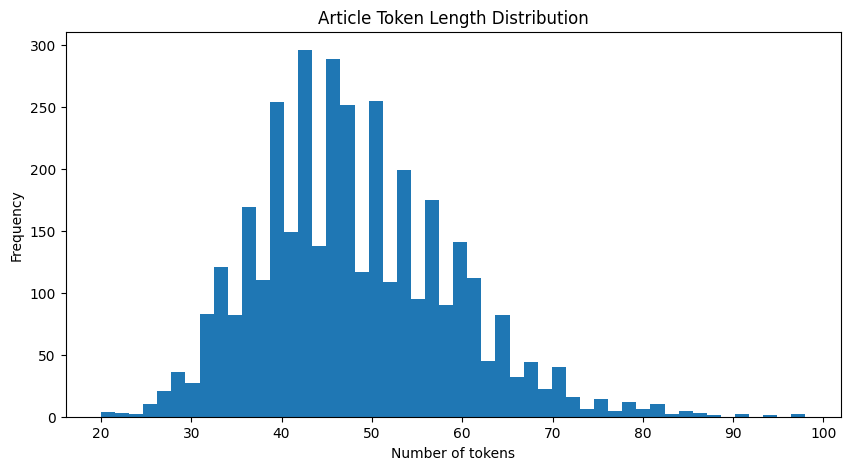

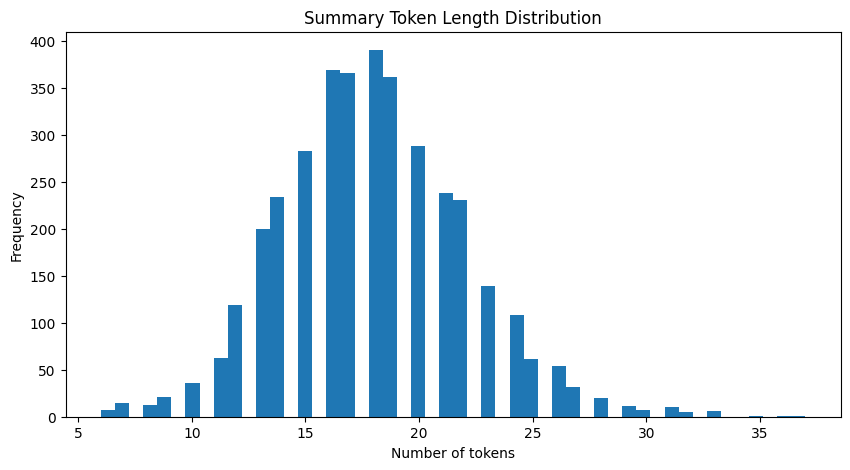

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["article_len"], bins=50)
plt.title("Article Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["summary_len"], bins=50)
plt.title("Summary Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

**Cell 19 — Filter empty or extremely short rows**

In [ ]:
df = df[
    (df["clean_article"].str.strip() != "") &
    (df["clean_summary"].str.strip() != "") &
    (df["article_len"] >= 5) &
    (df["summary_len"] >= 3)
].copy()

print("Shape after filtering:", df.shape)

Shape after filtering: (3689, 8)


**Cell 20 — Save a cleaned version**

In [ ]:
OUTPUT_DIR = Path("./processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

folder_name = selected_file.parent.name
file_name = selected_file.stem  
output_path = OUTPUT_DIR / f"cleaned_{folder_name}_{file_name}.csv"

df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("Saved cleaned dataset to:", output_path.resolve())

Saved cleaned dataset to: C:\Users\moham\Desktop\NLP_Project\processed_data\cleaned_data_train-00000-of-00001.csv
